In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from dotenv import load_dotenv
from pydantic_settings import BaseSettings

load_dotenv()


class Secrets(BaseSettings):
    db_user: str
    db_password: str
    db_host: str
    db_port: str
    db_name: str
    db_table_raw_meat: str

    class Config:
        env_file = ".env"
        env_file_encoding = "utf-8"


secrets = Secrets()

In [ ]:
url = f'mysql+pymysql://{secrets.db_user}:{secrets.db_password}@{secrets.db_host}:{secrets.db_port}/{secrets.db_name}'

engine = create_engine(url)
with engine.connect() as conn:
    df = pd.read_sql(
        f'''
        SELECT *
        FROM {secrets.db_table_raw_meat}
        WHERE date >= '2023-01-01'
        ''',
        conn,
        index_col='id'
    )

In [ ]:
df

In [ ]:
df['product'].unique()

In [ ]:
class DataPlot():
    def __init__(self,
                 data,
                 product_names=None,
                 okrug_names=None,
                 country_names=None,
                 product_threshold=0,
                 okrug_threshold=0,
                 country_threshold=0,
                 data_count_threshold=20,
                 xticks_range = range(0, 53, 2)
                 ):
        self.data = data
        self.product_names = product_names if product_names is not None else self.data['product_type'].unique().tolist()
        self.okrug_names = okrug_names if okrug_names is not None else self.data['federal_okrug'].unique().tolist()
        self.country_names = country_names if country_names is not None else self.data['country'].unique().tolist()
        self.product_threshold = product_threshold
        self.okrug_threshold = okrug_threshold
        self.country_threshold = country_threshold
        self.data_count_threshold = data_count_threshold
        self.colors = ['b', 'g', 'y', 'r', 'm', 'c', 'k', 'orange', *[np.random.rand(3,) for _ in range(0, 20)]]
        self.xticks_range = xticks_range

    def plot(self):
        df = self.data
        for category in df['product_type'].unique().tolist():

            # не рисуем графики если данных очень мало
            if len(df[(df['product_type'] == category)]) < self.data_count_threshold:
                continue

            fig, ax = plt.subplots(3, 2, figsize=(24, 16), width_ratios=[3, 1])
            fig.suptitle(category)

            # график динамики по типу продукта
            corr_df = []
            for  color, product in enumerate(self.product_names):
                data = df[(df['product_type'] == category) & (df['product'] == product)]
                if len(data) > self.product_threshold:
                    g = data.groupby('week_number').mean('price')
                    ax[0, 0].plot(g['price'], label=f'{product} - {len(data)}', color=self.colors[color], alpha=0.3)
                    ax[0, 0].plot(g['price'].rolling(5, center=True).mean(), linestyle='--', color=self.colors[color], alpha=0.8)
                    corr_df.append(g['price'].rename(product))

            # график корреляции по типу продукта
            if len(corr_df) > 0:
                corr = pd.concat(corr_df, axis=1).corr()
                sns.heatmap(corr, vmin=-1, vmax=1, annot=True, ax=ax[0, 1])
                ax[0, 1].title.set_text('Корреляция')

            # график динамики по федеральным округам
            corr_df = []
            for color, okrug in enumerate(self.okrug_names):
                data = df[(df['product_type'] == category) & (df['federal_okrug'] == okrug)]
                if len(data) > self.okrug_threshold:
                    g = data.groupby('week_number').mean('price')
                    ax[1, 0].plot(g['price'].rolling(5, center=True).mean(), label=f'{okrug} - {len(data)}', linestyle='--', color=self.colors[color], alpha=0.8)
                    corr_df.append(g['price'].rename(okrug))

            # график корреляции по федеральным округам
            # так как по округам недели загрузки могут быть разными, заполняем пустые значения с помощью линейной интерполяции
            if len(corr_df) > 0:
                corr = pd.concat(corr_df, axis=1).sort_index().interpolate('linear').bfill().corr()
                sns.heatmap(corr, vmin=-1, vmax=1, annot=True, ax=ax[1, 1], fmt='.2f')
                ax[1, 1].title.set_text('Корреляция')

            # график динамики по странам
            corr_df = []
            for color, country in enumerate(self.country_names):
                data = df[(df['product_type'] == category) & (df['country'] == country)]
                if len(data) > self.country_threshold:
                    g = data.groupby('week_number').mean('price')
                    ax[2, 0].plot(g['price'], label=f'{country} - {len(data)}', color=self.colors[color], alpha=0.3)
                    ax[2, 0].plot(g['price'].rolling(5, center=True).mean(), linestyle='--', color=self.colors[color], alpha=0.8)
                    corr_df.append(g['price'].rename(country))

            # график корреляции по странам
            if len(corr_df) > 0:
                corr = pd.concat(corr_df, axis=1).sort_index().interpolate('linear').bfill().corr()
                sns.heatmap(corr, vmin=-1, vmax=1, annot=True, ax=ax[2, 1], fmt='.2f')
                ax[2, 1].title.set_text('Корреляция')

            # добавление описания графиков
            for i, title in [(0, 'Динамика по типу продукта'), (1, 'Динамика по федеральному округу'), (2, 'Динамика по странам')]:
                if self.xticks_range:
                    ax[i, 0].set_xticks(range(0, 53, 2))
                ax[i, 0].plot([], alpha=1, label='Скользящее среднее', linestyle='--', color='grey')  # фейковый ряд для отображения в легенде
                ax[i, 0].legend(loc='upper left')
                ax[i, 0].title.set_text(title)
                ax[i, 0].set_xlabel('Номер недели')
                ax[i, 0].set_ylabel('Цена руб')

            fig.tight_layout()
            plt.plot()

In [ ]:
bdf = df[df['product'].isin(['Цыпленок', 'Индейка', 'Кура'])]
bdf = bdf[['product', 'description',
       'country',
       'price', 'activity_type',
       'date', 'product_type', 'sort', 'certification',
       'federal_okrug',  'week_number']]
bdf = bdf[bdf['product_type'].notna()]

DataPlot(
    data=bdf,
    product_names=['Кура', 'Цыпленок', 'Индейка'],
    okrug_names=None,
    country_names=['Россия', 'Китай', 'Казахстан', 'Бразилия', 'Белоруссия'],
 ).plot()

In [ ]:
beefdf = df[df['product'].isin(['Говядина', 'Телятина', 'Буйволятина'])]
beefdf = beefdf[['product', 'description',
                 'country',
                 'price', 'activity_type',
                 'date', 'product_type', 'sort', 'certification',
                 'federal_okrug',  'week_number']]

beefdf = beefdf[beefdf['product_type'].notna()]

DataPlot(
    data=beefdf,
    product_names=['Говядина', 'Телятина', 'Буйволятина'],
    okrug_names=None,
    country_names=['Россия', 'Аргентина', 'Парагвай', 'Бразилия', 'Белоруссия'],
    country_threshold=10
).plot()

In [ ]:
pdf = df[df['product'].isin(['Свинина'])]
pdf = pdf[['product', 'description',
           'country',
           'price', 'activity_type',
           'date', 'product_type', 'sort', 'certification',
           'federal_okrug',  'week_number']]

pdf = pdf[pdf['product_type'].notna()]

DataPlot(
    data=pdf,
    product_names=['Свинина'],
    okrug_names=None,
    country_names=['Россия', 'Бразилия'],
    country_threshold=10
).plot()

In [ ]:
mdf = df[df['product'].isin(['Баранина', 'Ягнятина'])]
mdf = mdf[['product', 'description',
       'country',
       'price', 'activity_type',
       'date', 'product_type', 'sort', 'certification',
       'federal_okrug',  'week_number']]

mdf = mdf[mdf['product_type'].notna()]

DataPlot(
    data=mdf,
    product_names=['Баранина', 'Ягнятина'],
    okrug_names=None,
    country_names=['Россия', 'Уругвай'],
).plot()

## Результаты анализа

- Есть записи которые имеют аномальную цену, х100 от медианы, например (id 394431, 394431)
- Есть небольшое количество записей, где явно цена указана не за кг, а за несколько (id 2569658)
- Могут быть записи с ошибочной категорией у которых цена сильно выше/ниже медианной цены


При построении модели предсказания цены, как вариант, можно удалять 5% аномальных записей по цене в каждой категории

В некоторых категориях цены в СЗФО сильно ниже, чем в других округах. Это связано с малым количеством данных по этому округу.

слабо объяснимые аномалии:
- "Окорочка" индейки, всего 1503 за все мониторинги, но до 2019 года записи равномерно распределены. С 2019-2022 записей 0, а с 2022 по 2025 есть только 8 записей
- "Филе грудки" курицы/цыпленка, всего 22 записи и все они за ноябрь, декабрь 2024, когда для индейки есть на протяжении всего мониторинга
- Свиные "черева" аномальный разброс цен, половина записей до ~50р, остальная половина ~2500р. Причем есть записи от одного продавца в двух половинах, с разным описанием тары

Могут быть категории из других продуктов, например в курице категория из говядины

Есть конкретный трейдер который ставит цену с коэффициентом 1.5-2 от говядины/баранины и продает телятину/ягнятину. За частую он продает ее один единственный в этой категории. Возможно стоит как-то обработать этот момент.


company ИП Егоров А.К.

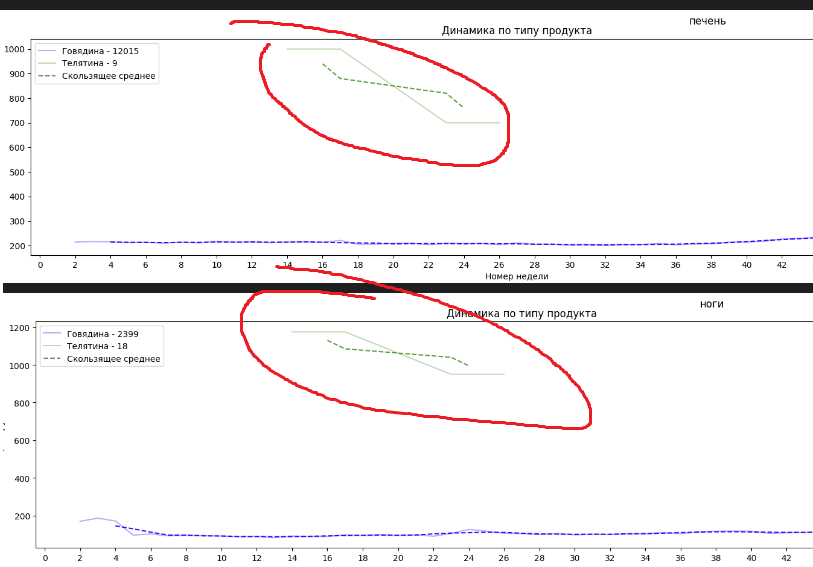

в Свинине есть общий тренд на повышение цены с пиком в конце года, практически в каждой категории. Надо посмотреть данные за несколько лет, возможно это сезонный тренд

In [ ]:
engine = create_engine(url)
with engine.connect() as conn:
    pig_4y_df = pd.read_sql(
        f'''
        SELECT *
        FROM {secrets.db_table_raw_meat}
        WHERE date >= '2020-01-01'
        AND product = 'Свинина'
        ''',
        conn,
        index_col='id'
    )

In [ ]:
pig_4y_df = pig_4y_df[['product', 'description',
           'country',
           'price', 'activity_type',
           'date', 'product_type', 'sort', 'certification',
           'federal_okrug',  'week_number']]

pig_4y_df = pig_4y_df[pig_4y_df['product_type'].notna()]
pig_4y_df['year'] = pig_4y_df['date'].dt.year
pig_4y_df['week_number'] = pig_4y_df['week_number'] + (pig_4y_df['year'] - pig_4y_df['year'].min())*52
pig_4y_df

In [ ]:
DataPlot(
    data=pig_4y_df,
    product_names=['Свинина'],
    okrug_names=None,
    country_names=['Россия', 'Бразилия'],
    country_threshold=10,
    xticks_range=None,
    data_count_threshold=5000
).plot()